# Traffic Sign Recognition Project
This notebook includes data loading, preprocessing, training a Custom CNN, and MobileNetV2 comparison.

## Import Libraries

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
import seaborn as sns

## Load and Preprocess Dataset

In [3]:
data = []
labels = []

img_size = 32
data_path = "GTSRB/Train"

for class_id in range(43):
    class_path = os.path.join(data_path, str(class_id))
    for img_name in os.listdir(class_path):

        if not img_name.lower().endswith(".png"):
            continue

        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        data.append(img)
        labels.append(class_id)

data = np.array(data)
labels = np.array(labels)

data = data / 255.0
labels = to_categorical(labels, 43)

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, shuffle=True)

## Build Custom CNN Model

In [4]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(43, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Data Augmentation and Training

In [5]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

history = model.fit(datagen.flow(X_train, y_train, batch_size=64),
                    epochs=15,
                    validation_data=(X_test, y_test))

Epoch 1/15
491/491 [==============================] - 15s 19ms/step - loss: 2.6110 - accuracy: 0.2703 - val_loss: 1.4669 - val_accuracy: 0.5720
Epoch 2/15
491/491 [==============================] - 10s 21ms/step - loss: 1.5730 - accuracy: 0.5015 - val_loss: 0.8697 - val_accuracy: 0.7535
Epoch 3/15
491/491 [==============================] - 9s 18ms/step - loss: 1.1880 - accuracy: 0.6119 - val_loss: 0.5805 - val_accuracy: 0.8326
Epoch 4/15
491/491 [==============================] - 19s 40ms/step - loss: 0.9889 - accuracy: 0.6754 - val_loss: 0.3965 - val_accuracy: 0.8988
Epoch 5/15
491/491 [==============================] - 22s 45ms/step - loss: 0.8462 - accuracy: 0.7224 - val_loss: 0.3145 - val_accuracy: 0.9189
Epoch 6/15
491/491 [==============================] - 15s 31ms/step - loss: 0.7318 - accuracy: 0.7600 - val_loss: 0.2273 - val_accuracy: 0.9438
Epoch 7/15
491/491 [==============================] - 9s 18ms/step - loss: 0.6617 - accuracy: 0.7799 - val_loss: 0.1879 - val_accuracy: 0

## Evaluate CNN

In [6]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

acc_cnn = accuracy_score(y_true_labels, y_pred_labels)
f1_cnn = f1_score(y_true_labels, y_pred_labels, average='weighted')
cm_cnn = confusion_matrix(y_true_labels, y_pred_labels)

print("\nCustom CNN Accuracy:", acc_cnn)
print("\nCustom CNN Classification Report:")
print(classification_report(y_true_labels, y_pred_labels))
print("Custom CNN F1-Score:", f1_cnn)
print("\nCustom CNN Confusion Matrix:")
print(cm_cnn)

model.save("traffic_sign_model.h5")

246/246 [==============================] - 0s 1ms/step

Custom CNN Accuracy: 0.9843152257077277

Custom CNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        41
           1       0.99      0.98      0.99       468
           2       0.98      0.98      0.98       442
           3       0.97      0.96      0.96       292
           4       0.99      1.00      0.99       411
           5       0.94      0.96      0.95       385
           6       1.00      1.00      1.00        82
           7       0.99      0.90      0.94       276
           8       0.89      0.99      0.94       284
           9       0.99      1.00      1.00       274
          10       1.00      0.99      1.00       405
          11       0.99      1.00      0.99       251
          12       1.00      1.00      1.00       388
          13       1.00      1.00      1.00       440
          14       1.00      1.00      1.00       164
    

## CNN Accuracy Plot

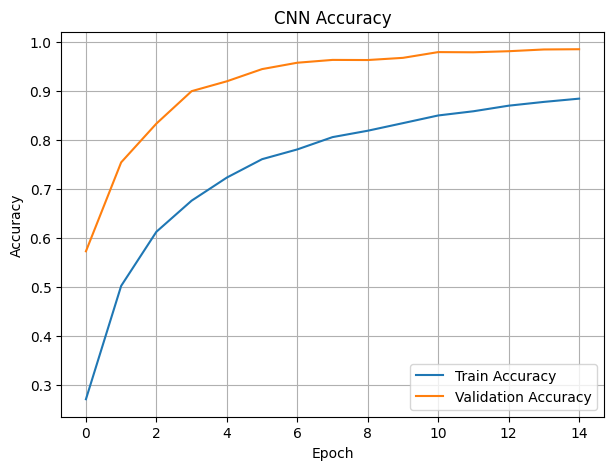

In [7]:
plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## CNN Loss Plot

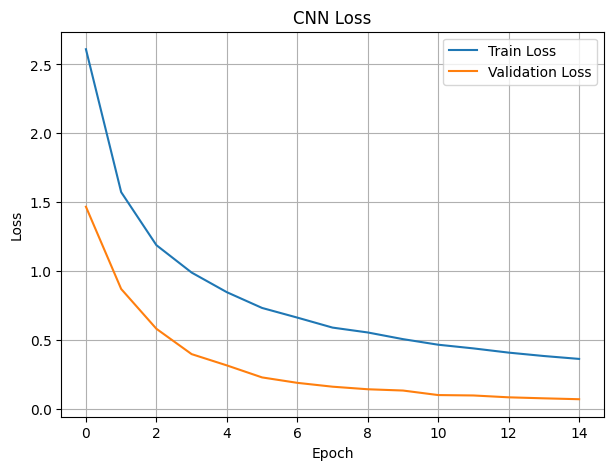

In [8]:
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Load MobileNetV2 and Freeze Layers

In [19]:
base_model = MobileNetV2(weights=None, include_top=False, input_shape=(32,32,3))

for layer in base_model.layers:
    layer.trainable = False

## Build MobileNetV2 Model

In [10]:
model_mobilenet = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(43, activation='softmax')
])

model_mobilenet.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

## Train MobileNetV2

In [11]:
history_mobilenet = model_mobilenet.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=15,
    validation_data=(X_test, y_test)
)

Epoch 1/15
491/491 [==============================] - 21s 41ms/step - loss: 2.9138 - accuracy: 0.2010 - val_loss: 2.5447 - val_accuracy: 0.2731
Epoch 2/15
491/491 [==============================] - 10s 20ms/step - loss: 2.5409 - accuracy: 0.2602 - val_loss: 2.3973 - val_accuracy: 0.3017
Epoch 3/15
491/491 [==============================] - 10s 20ms/step - loss: 2.4460 - accuracy: 0.2811 - val_loss: 2.3371 - val_accuracy: 0.3114
Epoch 4/15
491/491 [==============================] - 10s 20ms/step - loss: 2.3894 - accuracy: 0.2916 - val_loss: 2.2860 - val_accuracy: 0.3238
Epoch 5/15
491/491 [==============================] - 10s 20ms/step - loss: 2.3579 - accuracy: 0.2995 - val_loss: 2.2523 - val_accuracy: 0.3271
Epoch 6/15
491/491 [==============================] - 10s 20ms/step - loss: 2.3308 - accuracy: 0.3072 - val_loss: 2.2269 - val_accuracy: 0.3319
Epoch 7/15
491/491 [==============================] - 10s 20ms/step - loss: 2.3069 - accuracy: 0.3097 - val_loss: 2.2041 - val_accuracy:

## Evaluate MobileNetV2

In [18]:
y_pred_m = model_mobilenet.predict(X_test)
y_pred_labels_m = np.argmax(y_pred_m, axis=1)
y_true_labels_m = np.argmax(y_test, axis=1)

acc_mobilenet = accuracy_score(y_true_labels_m, y_pred_labels_m)
f1_mobilenet = f1_score(y_true_labels_m, y_pred_labels_m, average='weighted')
cm_mobilenet = confusion_matrix(y_true_labels_m, y_pred_labels_m)

print("\nMobileNetV2 Accuracy:", acc_mobilenet)
print("\nMobileNetV2 Classification Report:")
print(classification_report(y_true_labels_m, y_pred_labels_m, zero_division=0))
print("MobileNetV2 F1-Score:", f1_mobilenet)
print("\nMobileNetV2 Confusion Matrix:")
print(cm_mobilenet)

model_mobilenet.save("traffic_sign_mobilenetv2.h5")

246/246 [==============================] - 1s 5ms/step

MobileNetV2 Accuracy: 0.3625350675847998

MobileNetV2 Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.02      0.05        41
           1       0.35      0.43      0.38       468
           2       0.26      0.40      0.32       442
           3       0.34      0.18      0.24       292
           4       0.26      0.28      0.27       411
           5       0.27      0.28      0.27       385
           6       0.63      0.32      0.42        82
           7       0.24      0.20      0.22       276
           8       0.22      0.14      0.17       284
           9       0.43      0.35      0.39       274
          10       0.34      0.41      0.37       405
          11       0.26      0.31      0.28       251
          12       0.37      0.77      0.50       388
          13       0.56      0.78      0.65       440
          14       0.44      0.62      0.51       164
  

## Confusion Matrix CNN

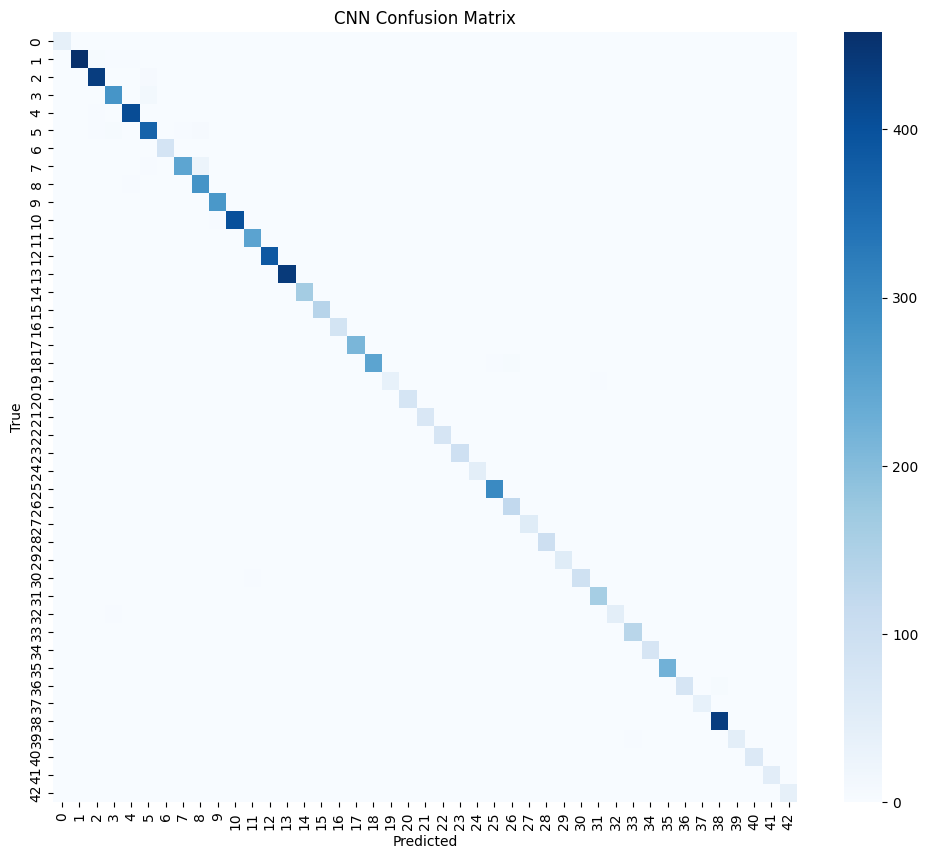

In [13]:
plt.figure(figsize=(12,10))
sns.heatmap(cm_cnn, cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Confusion Matrix MobileNetV2

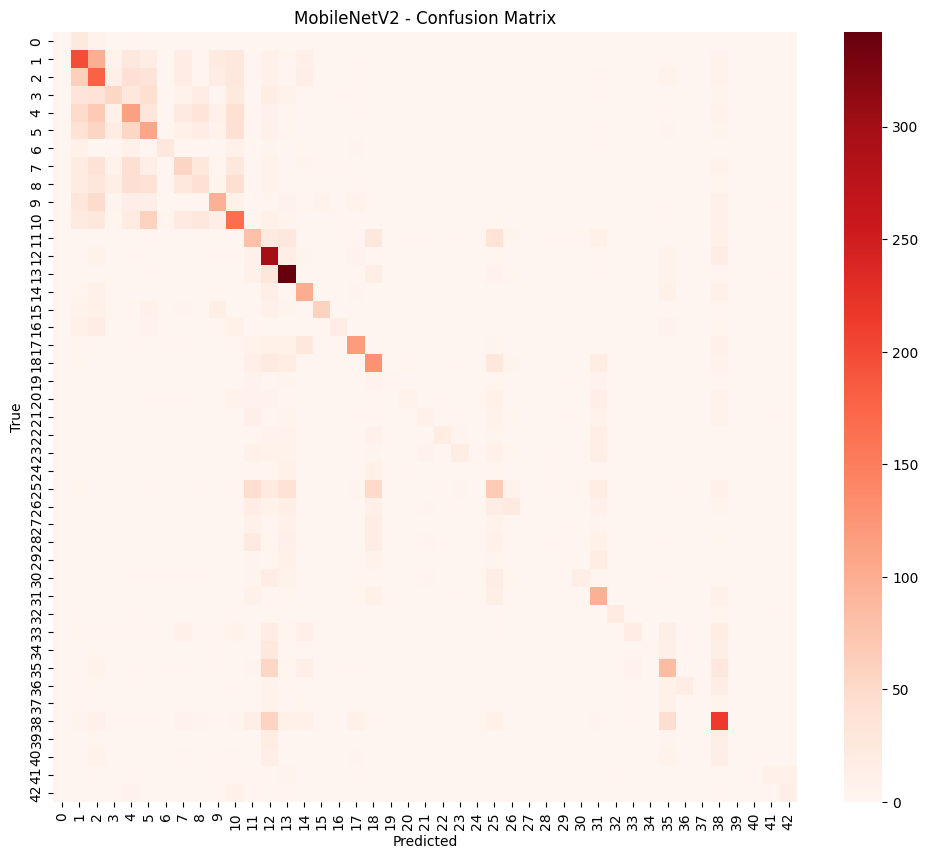

In [14]:
plt.figure(figsize=(12,10))
sns.heatmap(cm_mobilenet, cmap="Reds")
plt.title("MobileNetV2 - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## MobileNetV2 Accuracy Plot

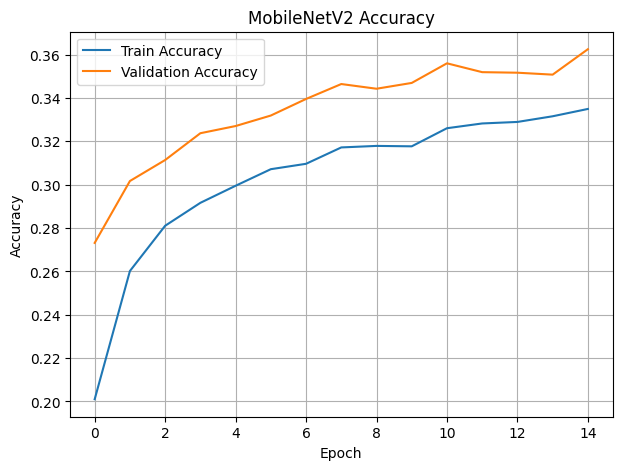

In [15]:
plt.figure(figsize=(7,5))
plt.plot(history_mobilenet.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## MobileNetV2 Loss Plot

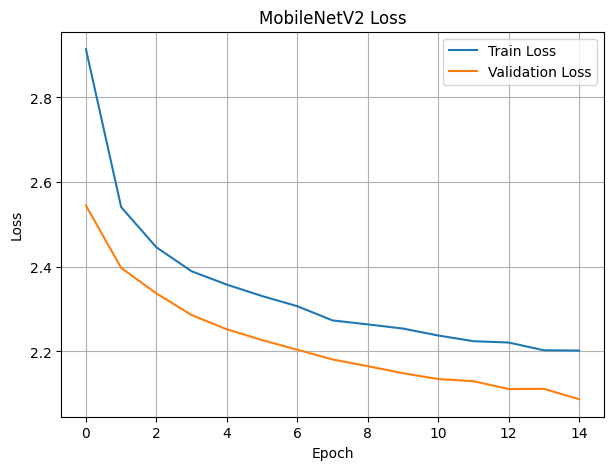

In [16]:
plt.figure(figsize=(7,5))
plt.plot(history_mobilenet.history['loss'], label='Train Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Final Comparison

In [17]:
print("====== Final Model Comparison ======")
print(f"Custom CNN Accuracy:      {acc_cnn:.4f}")
print(f"MobileNetV2 Accuracy:     {acc_mobilenet:.4f}")
print("-------------------------------------")
print(f"Custom CNN F1 Score:      {f1_cnn:.4f}")
print(f"MobileNetV2 F1 Score:     {f1_mobilenet:.4f}")
print("=====================================")

====== Final Model Comparison ======
Custom CNN Accuracy:      0.9843
MobileNetV2 Accuracy:     0.3625
-------------------------------------
Custom CNN F1 Score:      0.9843
MobileNetV2 F1 Score:     0.3398
